# Semana 3 - Análisis Micro: Estadios de Desarrollo de la Inclusión Digital
**CC3074 - Minería de Datos | Semestre I, 2026**

El desarrollo tecnológico en sociedades latinoamericanas no es un estado fijo sino un proceso dinámico. Etiquetar a un país de forma estática ignora su capacidad de transformación histórica. 
Este análisis utiliza observaciones de país por año para tratar a la inclusión digital como un recorrido evolutivo. 
El objetivo no es simplemente clasificar naciones, sino descubrir los Arquetipos de Inclusión. Estos arquetipos funcionan como hitos por los que transita cualquier nación en su camino a la digitalización. Esta metodología permite medir con precisión la ubicación actual de cada país y la velocidad con la que alcanza niveles superiores de madurez.

## 1. Configuración e Importaciones
Centralizar parámetros como la semilla, rutas y nombres garantiza la reproducibilidad. En un entorno de investigación, cualquier cambio en la semilla de aleatoriedad o en la fuente de datos debe ser fácil de rastrear y modificar en un solo punto para evitar inconsistencias en los resultados finales.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, BisectingKMeans
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

import warnings
warnings.filterwarnings('ignore')

CONFIG = {
    'SEED': 42,
    'DATA_PATH': 'data_per_age_group.csv',
    'OUTPUT_DIR': 'plots',
    'PALETTE': ['#C084FC', '#F472B6', '#60A5FA', '#34D399', '#FBBF24'],
    'FEATURES': {
        'edad de medicion a 17 años': 'u17',
        '18 a 25 años de edad': '18_25',
        '26 a 50 años de edad': '26_50',
        '51 a 65 años': '51_65',
        '66 años en adelante': 'o66'
    },
    'COUNTRY_CLEANUP': {
        'Bolivia (Estado Plurinacional de)': 'Bolivia'
    }
}

if not os.path.exists(CONFIG['OUTPUT_DIR']):
    os.makedirs(CONFIG['OUTPUT_DIR'])

plt.rcParams.update({'figure.dpi': 120, 'font.family': 'DejaVu Sans',
                     'axes.spines.top': False, 'axes.spines.right': False})

print('Configuración cargada ✓')

Configuración cargada ✓


## 2. Carga y Normalización (ETL)

1. **Renombrado Estratégico:** El uso de etiquetas cortas como u17 y o66 optimiza el procesamiento de datos. Facilita la legibilidad del código y reduce la probabilidad de errores al manipular las variables de los distintos grupos generacionales.
2. **Estandarización Global:** Esta es la decisión técnica más relevante del proceso. Al escalar todos los años bajo una misma métrica, aseguramos que la comparación sea absoluta y no relativa. Esto significa que un nivel de desarrollo identificado en el pasado tiene el mismo peso que uno actual. Escalar de forma independiente por año ocultaría el crecimiento real del continente, ya que la vara de medición cambiaría en cada ciclo.

In [2]:
def load_and_preprocess():
    df = pd.read_csv(CONFIG['DATA_PATH'])
    df = df.rename(columns=CONFIG['FEATURES'])
    FEATURE_COLS = list(CONFIG['FEATURES'].values())
    df['country_short'] = df['country'].replace(CONFIG['COUNTRY_CLEANUP'])
    df = df.dropna(subset=FEATURE_COLS).copy()
    X_scaled = StandardScaler().fit_transform(df[FEATURE_COLS])
    return df, X_scaled, FEATURE_COLS

df, X_scaled, FEATURE_COLS = load_and_preprocess()
print(f'Dataset procesado: {df.shape}')

Dataset procesado: (145, 9)


## 3. Selección de K: El Dilema entre Matemáticas y Sociología
El coeficiente de Silueta sugiere un valor de K igual a dos como la opción más robusta estadísticamente. Esto ocurre porque existe una brecha histórica muy marcada entre el aislamiento del pasado y la conexión actual. El modelo tiende a simplificar la realidad en dos grupos opuestos.

En el contexto social, el objetivo de la minería de datos es orientar decisiones de gobierno. Un análisis dividido solo en dos partes es insuficiente para diseñar estrategias de intervención. Se opta por utilizar tres grupos para capturar la complejidad de la transición digital. Esta decisión permite identificar con claridad a los países que ya integraron a sus jóvenes pero que todavía tienen dificultades para incluir a los sectores de mayor edad en el ecosistema digital.

K seleccionado por valor sociológico: 3 (Silhouette: 0.4629)


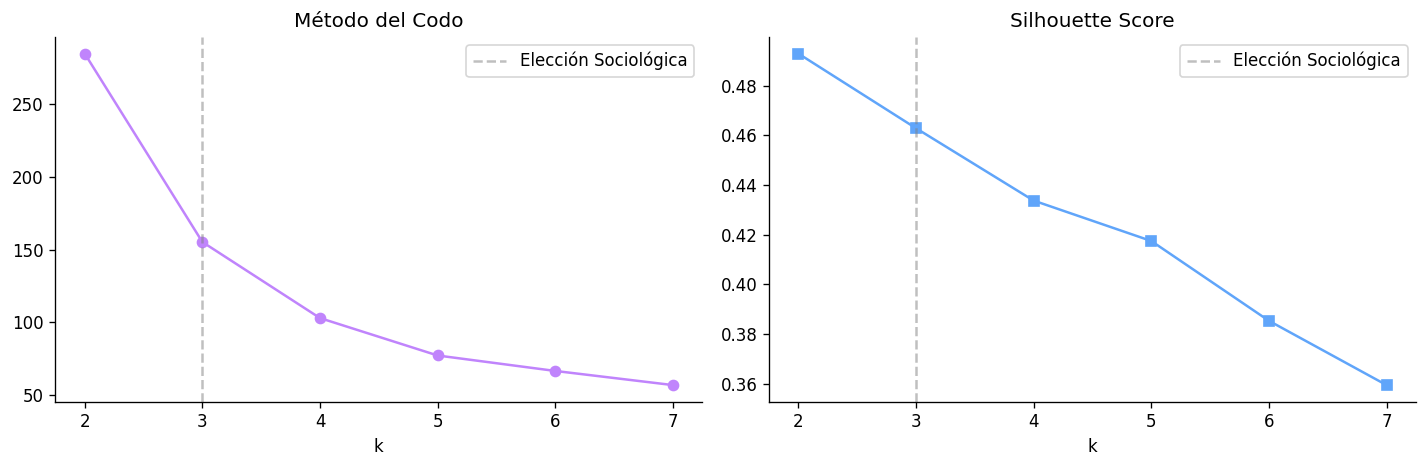

In [3]:
def evaluate_k(X):
    K_RANGE = range(2, 8)
    metrics = {'inertia': [], 'silhouette': []}
    for k in K_RANGE:
        km = KMeans(n_clusters=k, init='k-means++', n_init=50, random_state=CONFIG['SEED'])
        lbl = km.fit_predict(X)
        metrics['inertia'].append(km.inertia_)
        metrics['silhouette'].append(silhouette_score(X, lbl))
    return metrics, K_RANGE

METRICS, K_RANGE = evaluate_k(X_scaled)

K_OPT = 3
print(f'K seleccionado por valor sociológico: {K_OPT} (Silhouette: {METRICS["silhouette"][1]:.4f})')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(K_RANGE, METRICS['inertia'], 'o-', color=CONFIG['PALETTE'][0])
ax1.axvline(K_OPT, ls='--', color='gray', alpha=0.5, label='Elección Sociológica')
ax1.set_title('Método del Codo'); ax1.set_xlabel('k'); ax1.legend()

ax2.plot(K_RANGE, METRICS['silhouette'], 's-', color=CONFIG['PALETTE'][2])
ax2.axvline(K_OPT, ls='--', color='gray', alpha=0.5, label='Elección Sociológica')
ax2.set_title('Silhouette Score'); ax2.set_xlabel('k'); ax2.legend()
plt.tight_layout(); plt.show()

## 4. Modelado y Re-ordenamiento de Estadios

Los algoritmos de agrupación asignan etiquetas de forma arbitraria sin considerar un orden lógico. Para un análisis de desarrollo, es fundamental que los números tengan una secuencia coherente. Se aplica un proceso de reordenamiento basado en el promedio de inclusión de cada grupo. Esto garantiza que el Estadio 0 represente siempre el nivel inicial y el Estadio 2 el nivel más avanzado. Esta coherencia es esencial para que las visualizaciones de progreso muestren un avance ascendente fácil de interpretar por cualquier lector.

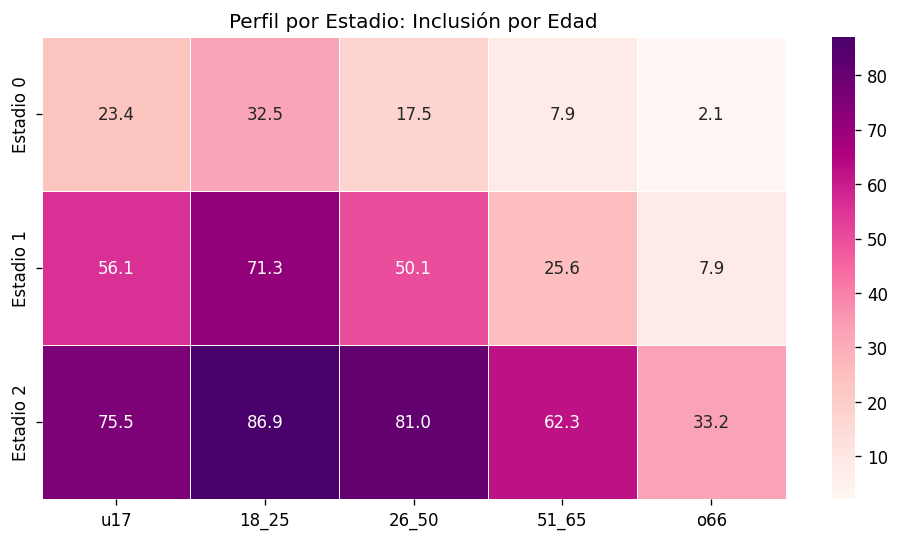

In [4]:
km = KMeans(n_clusters=K_OPT, init='k-means++', n_init=100, random_state=CONFIG['SEED'])
df['estadio_raw'] = km.fit_predict(X_scaled)

# Ordenar estadios por nivel de inclusión
cluster_order = df.groupby('estadio_raw')[FEATURE_COLS].mean().mean(axis=1).sort_values().index
map_ord = {old: new for new, old in enumerate(cluster_order)}
df['estadio'] = df['estadio_raw'].map(map_ord)

perfil = df.groupby('estadio')[FEATURE_COLS].mean()
perfil.index = [f'Estadio {i}' for i in perfil.index]

plt.figure(figsize=(10, 5))
sns.heatmap(perfil, annot=True, fmt='.1f', cmap='RdPu', linewidths=0.5)
plt.title('Perfil por Estadio: Inclusión por Edad')
plt.show()

## 5. Visualización de Trayectorias y Evolución Regional

1. **Cronograma de Estadios:** El mapa de calor por país funciona como un registro histórico del desarrollo. Permite localizar con exactitud los años de mejora institucional y el impacto de los planes nacionales de conectividad en el cambio de etapa.
2. **Composición Regional:** Este gráfico de área muestra la tendencia del bloque latinoamericano. Ayuda a visualizar si la región se está moviendo hacia una mayor equidad o si la distancia entre las naciones líderes y las rezagadas se mantiene constante.
3. **Trayectorias en Espacio Reducido:** El uso de componentes principales permite ver el movimiento social en dos dimensiones. La longitud de cada línea en el gráfico representa la magnitud del cambio estructural. Un recorrido largo significa que el país ha realizado una transformación profunda en el acceso digital de sus ciudadanos.

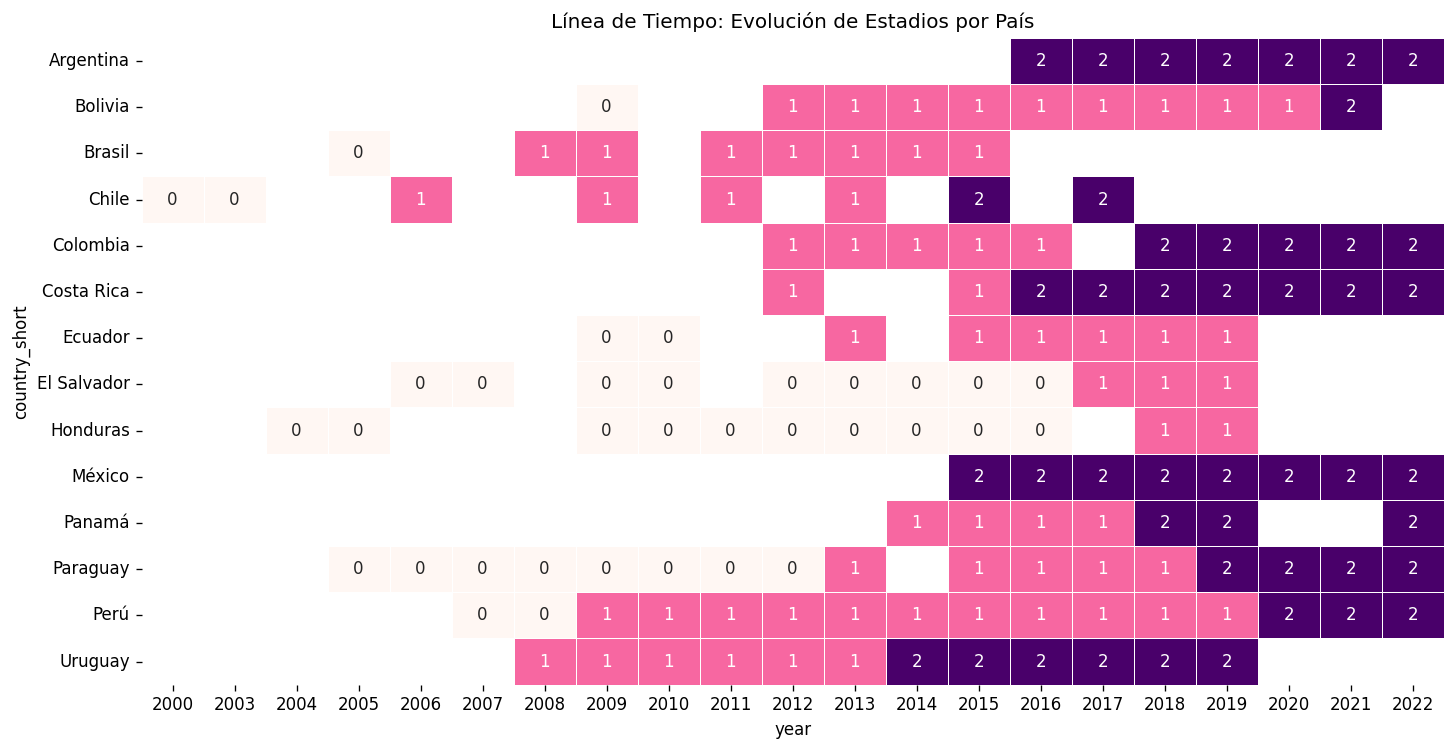

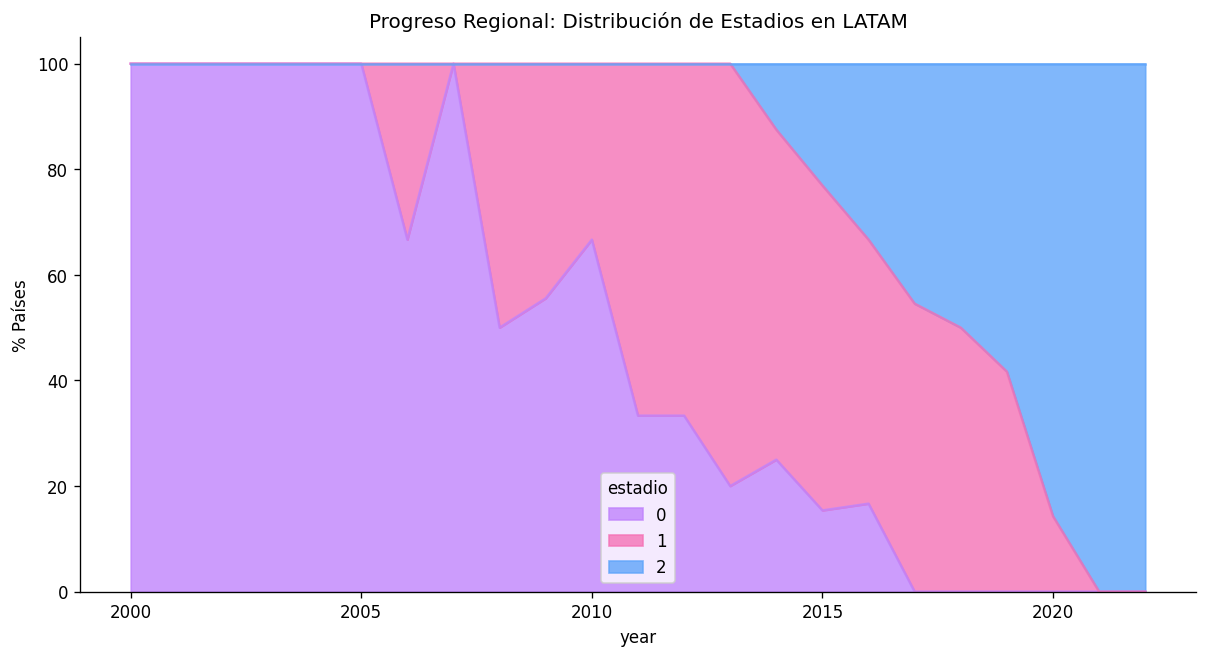

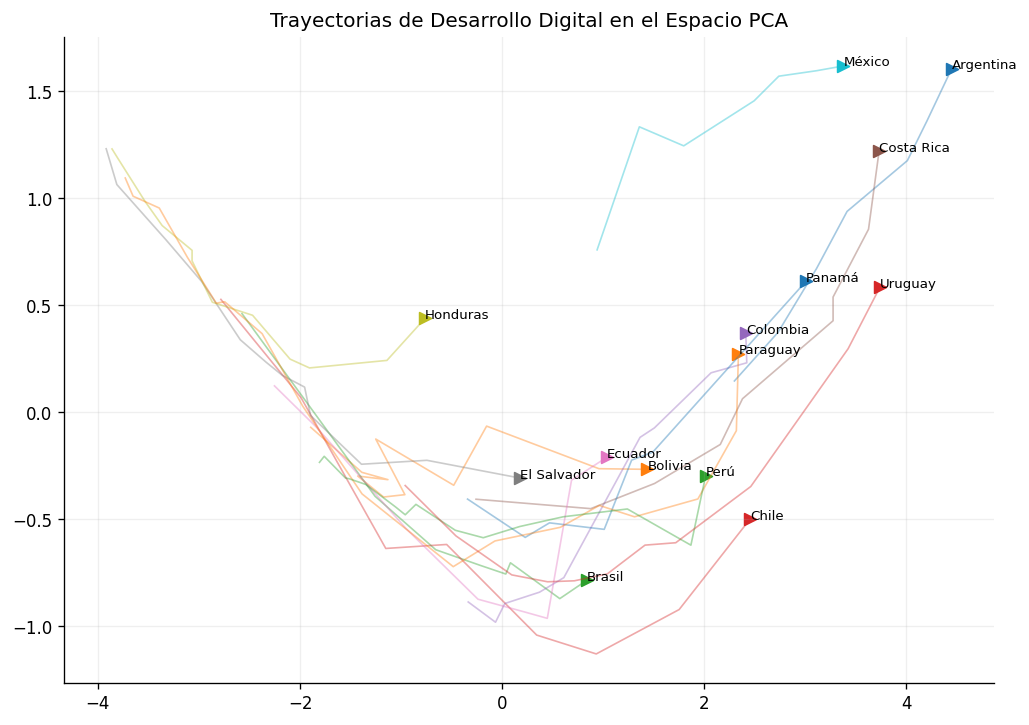

In [5]:
df_pivot = df.pivot(index='country_short', columns='year', values='estadio')
plt.figure(figsize=(14, 7))
sns.heatmap(df_pivot, annot=True, cmap='RdPu', cbar=False, linewidths=0.5)
plt.title('Línea de Tiempo: Evolución de Estadios por País')
plt.show()

regional = df.groupby(['year', 'estadio']).size().unstack(fill_value=0).pipe(lambda d: d.div(d.sum(axis=1), axis=0) * 100)
regional.plot(kind='area', stacked=True, alpha=0.8, color=CONFIG['PALETTE'], figsize=(12, 6))
plt.title('Progreso Regional: Distribución de Estadios en LATAM')
plt.ylabel('% Países'); plt.show()

X_pca = PCA(n_components=2, random_state=CONFIG['SEED']).fit_transform(X_scaled)
df['pc1'], df['pc2'] = X_pca[:, 0], X_pca[:, 1]
plt.figure(figsize=(10, 7))
for country in df['country_short'].unique():
    c_df = df[df['country_short'] == country].sort_values('year')
    plt.plot(c_df['pc1'], c_df['pc2'], alpha=0.4, lw=1)
    plt.scatter(c_df['pc1'].iloc[-1], c_df['pc2'].iloc[-1], marker='>', s=50)
    plt.annotate(country, (c_df['pc1'].iloc[-1], c_df['pc2'].iloc[-1]), fontsize=8)
plt.title('Trayectorias de Desarrollo Digital en el Espacio PCA')
plt.grid(True, alpha=0.2); plt.show()

## 6. Conclusiones y Limitaciones

La rigurosidad del estudio depende de reconocer sus fronteras. Este modelo proporciona una visión panorámica indispensable pero no exhaustiva. Los promedios nacionales son herramientas poderosas que sin embargo pueden ocultar brechas críticas entre regiones urbanas y rurales. También es necesario considerar que factores externos como crisis económicas o eventos globales pueden alterar el ritmo de las trayectorias observadas. Identificar estos puntos críticos permite que el modelo sea interpretado con cautela y sirve de base para futuros estudios más específicos.